# Extract sensitivity from histogram distribution

the first version uses continuous function + integral

now changed to histogram + sum


## steps:

- 1. modify the old function

- 2. sanity check with E_nr

- 3. extract curve from E_ee with lindhard model

- 4. implementing other yield models, extract more sensitivities

- 5. plot and make comparison


In [1]:
from analysis.sensitivity import get_Nexp_from_CL
from analysis.rate_models import get_rate_ben
from analysis.dm_params import DMParams
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from yield_functions import lindhard
from yield_functions import damicm_fit


## 1. modify the old function


In [2]:
def scan_sensitivity_hist(dm_params, rate_function, yield_function=lambda _: 1, lgmass_range = [-1, 2], lgxs_range = [-8, 0], npoints = 10, filetag = '', overwrite = False):
    contour_mass = []
    contour_xs = []
    lgmasses  = np.linspace(*lgmass_range, npoints)
    lgxses = np.linspace(*lgxs_range,npoints)

    for i, m_D in enumerate(tqdm(10**lgmasses, total=npoints, desc="Scanning m_D", unit="mass")):
        for j, xs in enumerate(10**lgxses):
            dm_params.m_D_GeV = m_D
            dm_params.sigma_pb = xs
            
            ##### start change for hists #####
            E_nr_min, E_nr_max = 0.001, 50.0     # keVnr (example)
            dE_nr = 0.005                      # fine recoil step for smooth remapping
            E_nr = np.arange(E_nr_min, E_nr_max + dE_nr, dE_nr)

            # Compute weights (expected counts per small recoil bin)
            weights = get_rate_ben(E_nr,dm_params) * dE_nr

            # Map to ionized (measured) energy
            E_ion = yield_function(E_nr) * E_nr   
            # E_ion = 1 * E_nr #ref

            # hist of E_ee
            Eion_min, Eion_max = 0, 10 # Example range
            Eion_width = 0.02
            Eion_edges = np.arange(Eion_min, Eion_max + Eion_width, Eion_width)
            Eion_centers = 0.5 * (Eion_edges[1:] + Eion_edges[:-1])
            hist_Eion, _ = np.histogram(E_ion, bins=Eion_edges, weights=weights)

            # only sum over the bins with energy > threshhold
            # threshhold = 0.63 * yield_function(0.63) # E_ee threshhold
            threshhold = 0.01 # KeV

            mask = Eion_centers > threshhold
            R_tot = hist_Eion[mask].sum()
            # print(R_tot)
            ##### end change for hists #####


            if abs(R_tot * dm_params.exposure_kgdays - get_Nexp_from_CL(dm_params.confidence_level)) < 0.1:
                contour_mass.append(m_D)
                contour_xs.append(xs)

    return np.array(contour_mass), np.array(contour_xs)

## 2. sanity check with E_nr

In [3]:
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 rho_GeV_cm3 = 0.3,
                 v0_kms = 238,
                 vE_kms = 263,
                 vesc_kms = 544,
                 exposure_kgdays = 365,
                 confidence_level = 0.9,
                 mass_number_A = 28,
                 c1 = 0.751, c2 = 0.561,
                 E_min_KeV= 0
                 )

In [4]:
# mass_test, xs_test = scan_sensitivity_hist(params, get_rate_ben, npoints=300)
# np.savez("NR/sensitivity_hist_ref.npz", mass=np.array(mass_test), xs=np.array(xs_test))

## 3. extract curve from E_ee with lindhard model


In [5]:
mass_lindhard, xs_lindhard = scan_sensitivity_hist(params, get_rate_ben, yield_function = lindhard,npoints=600)
np.savez("NR/sensitivity_hist_lindhard.npz", mass=np.array(mass_lindhard), xs=np.array(xs_lindhard))

Scanning m_D: 100%|██████████| 600/600 [11:35<00:00,  1.16s/mass]


In [6]:
mass_damicm, xs_damicm = scan_sensitivity_hist(params, get_rate_ben, yield_function = damicm_fit,npoints=600)
np.savez("NR/sensitivity_hist_damicm.npz", mass=np.array(mass_damicm), xs=np.array(xs_damicm))

Scanning m_D: 100%|██████████| 600/600 [10:40<00:00,  1.07s/mass]


In [7]:
# ref ben
# data_ben = np.load("NR/sensitivity_hist_ben.npz") 
# mass_ben, xs_ben = data_ben["mass"],data_ben["xs"]

# hist result ben:
# data_test = np.load("NR/sensitivity_hist_ref.npz") 
# mass_test, xs_test = data_test["mass"],data_test["xs"]

# lindhard yield:
# data_lindhard = np.load("NR/sensitivity_hist_lindhard.npz") 
# mass_lindhard, xs_lindhard = data_lindhard["mass"],data_lindhard["xs"]

# damicm yield:
# data_damicm = np.load("NR/sensitivity_hist_damicm.npz") 
# mass_damicm, xs_damicm = data_damicm["mass"],data_damicm["xs"]

<Figure size 1008x1440 with 0 Axes>

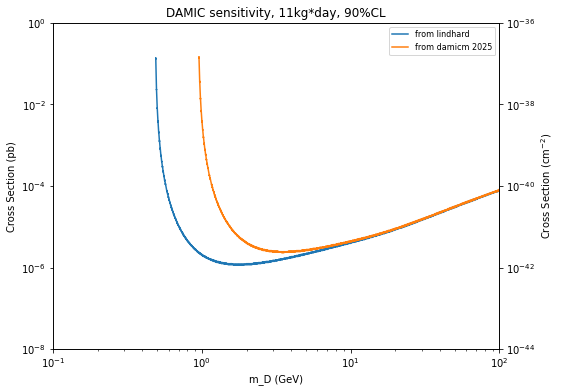

In [8]:
plt.figure(figsize=(14, 20))
fig, ax1 = plt.subplots(figsize=(8, 6))
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle
# ax1.plot(mass_ben, xs_ben, label='ref - yield =1 ')
# ax1.plot(mass_test, xs_test, label='yield = 1')
# rad_file = '/Users/iumicuszhu/Downloads/Default Dataset.csv'
# data_rad = np.loadtxt(rad_file, delimiter=",") 
# mass_rad, xs_rad = data_rad[:,0], data_rad[:,1]*1e36
# ax1.plot(data_rad, xs_rad, label='from radomir, yield = 1')

ax1.plot(mass_lindhard, xs_lindhard, label='from lindhard')
ax1.plot(mass_damicm, xs_damicm, label='from damicm 2025')


ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('DAMIC sensitivity, 11kg*day, 90%CL')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (pb)')
ax1.set_xlim(0.1,100)
ax1.set_ylim(1e-8,1e0)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title='new params')
ax1.legend(fontsize = 8)

plt.show()

fig.savefig("hist_sensitivity_plot2.png", dpi=600) 

## 4. implementing other yield models, extract more sensitivities

In [9]:
# from scipy.interpolate import PchipInterpolator  # monotone, no overshoot

# def build_yield_function(filename):
#     """Return a callable Y(E_nr) and (Egrid, Ygrid) used internally."""
#     data = np.loadtxt(filename, delimiter=",", dtype=float)
#     if data.shape[1] < 2:
#         raise ValueError("Expected at least two columns: E_nr[eV], yield")

#     E = data[:, 0] # unit = eV
#     Y = data[:, 1]

#     # Clean & sort
#     m = np.isfinite(E) & np.isfinite(Y)
#     E, Y = E[m], Y[m]
#     order = np.argsort(E)
#     E, Y = E[order], Y[order]

#     # Monotone spline across measured range (no extrapolation)
#     interp = PchipInterpolator(E, Y, extrapolate=False)
#     Emin, Emax = E[0], E[-1]

#     def Y_of_E(E_query):
#         """Vectorized yield function in same energy unit as the file (eV by default)."""
#         Earr = np.asarray(E_query * 1e3, dtype=float) # change to eV

#         mask_low  = Earr < Emin
#         mask_high = Earr > Emax
#         mask_mid  = ~(mask_low | mask_high)

#         out = np.empty_like(Earr, dtype=float)
#         # Below data: 0
#         out[mask_low] = 0.0
#         # Within data: interpolate
#         out[mask_mid] = interp(Earr[mask_mid])
#         # Above data: Lindhard (be sure units match; use lindhard_energy_scale if needed)
#         out[mask_high] = lindhard(Earr[mask_high])

#         # Return scalar if scalar input
#         return out if out.ndim else float(out)

#     return Y_of_E, (E, Y)


In [10]:
# yield_damicm, _ = build_yield_function('nuclear_yield/DAMIC 2025.csv')

In [11]:
# mass_damicm, xs_damicm = scan_sensitivity_hist(params, get_rate_ben, yield_function = yield_damicm, npoints=300)
# np.savez("NR/sensitivity_hist_damicm.npz", mass=np.array(mass_damicm), xs=np.array(xs_damicm))

## 5. plot and comparison

In [12]:
# plt.figure(figsize=(14, 20))
# fig, ax1 = plt.subplots(figsize=(8, 6))
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle
# ax1.plot(mass_ben, xs_ben, label='from integral')
# ax1.plot(mass_test, xs_test, label='from hist sum')
# ax1.plot(mass_lindhard, xs_lindhard, label='from lindhard')
# # ax1.plot(mass_damicm, xs_damicm, label='from damicm 2025')

# rad_file = '/Users/iumicuszhu/Downloads/Default Dataset.csv'
# data_rad = np.loadtxt(rad_file, delimiter=",") 
# mass_rad, xs_rad = data_rad[:,0], data_rad[:,1]*1e36
# ax1.plot(data_rad, xs_rad, label='from radomir, yield = 1')

# ax1.set_yscale("log")
# ax1.set_xscale("log")
# ax1.set_title('DAMIC sensitivity, 11kg*day, 90%CL')
# ax1.set_xlabel('m_D (GeV)')
# ax1.set_ylabel('Cross Section (pb)')
# ax1.set_xlim(1,10)
# ax1.set_ylim(1e-5,1e0)

# ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
# ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# # second axis
# ax2 = ax1.twinx()
# ax2.set_yscale("log")
# ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
# ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

# ax1.legend(title='v0 = 230km/s, Emin = 0.63 KeV, CL = 90%, Si A=28, 11kg*day, 95%CL')
# ax1.legend(fontsize = 8)

# plt.show()

# fig.savefig("hist_sensitivity_plot.png") 